# Warm-Start vs Baseline Pipeline Comparison

Side-by-side comparison of pipeline evaluation results:
- **Baseline**: `pipeline_eval_all_families.pkl`
- **Warm-start**: `pipeline_eval_all_families_warm_start.pkl`

In [2]:
import pickle, numpy as np, pandas as pd
from pathlib import Path

BASE_DIR = Path(r'C:\Users\Dell\projects\multilayer_milp_gnn\benchmark\outputs\pipeline_eval_criticality')

with open(BASE_DIR / 'pipeline_eval_all_families.pkl', 'rb') as f:
    baseline_raw = pickle.load(f)
with open(BASE_DIR / 'pipeline_eval_all_families_warm_start.pkl', 'rb') as f:
    warmstart_raw = pickle.load(f)

# Convert to dicts if dataclass
from dataclasses import asdict
def to_dict(r):
    return asdict(r) if hasattr(r, '__dataclass_fields__') else r

bl = pd.DataFrame([to_dict(r) for r in baseline_raw])
ws = pd.DataFrame([to_dict(r) for r in warmstart_raw])

print(f'Baseline:   {len(bl)} scenarios')
print(f'Warm-start: {len(ws)} scenarios')

Baseline:   300 scenarios
Warm-start: 300 scenarios


## 1. Global Summary Comparison

In [3]:
# Merge on scenario_id + family
merged = bl.merge(ws, on=['scenario_id', 'family'], suffixes=('_bl', '_ws'))
print(f'Matched scenarios: {len(merged)}')

# Key timing columns
time_cols = ['time_total', 'time_graph_build', 'time_embedding',
             'time_ebm_sampling', 'time_decoder', 'time_lp_solve']

print('\n' + '='*80)
print('  GLOBAL TIMING COMPARISON (seconds)')
print('='*80)
print(f'{"Metric":>20s} {"Baseline":>12s} {"Warm-start":>12s} {"Delta":>10s} {"Delta%":>8s}')
print('-'*65)
for col in time_cols:
    bl_col = f'{col}_bl' if f'{col}_bl' in merged.columns else col
    ws_col = f'{col}_ws' if f'{col}_ws' in merged.columns else col
    if bl_col in merged.columns and ws_col in merged.columns:
        bl_mean = merged[bl_col].mean()
        ws_mean = merged[ws_col].mean()
        delta = ws_mean - bl_mean
        pct = delta / bl_mean * 100 if bl_mean != 0 else 0
        print(f'{col:>20s} {bl_mean:12.2f} {ws_mean:12.2f} {delta:+10.2f} {pct:+7.1f}%')

Matched scenarios: 300

  GLOBAL TIMING COMPARISON (seconds)
              Metric     Baseline   Warm-start      Delta   Delta%
-----------------------------------------------------------------
          time_total       111.84       111.22      -0.62    -0.6%
    time_graph_build         0.20         0.22      +0.02   +11.6%
      time_embedding         0.07         0.07      -0.00    -0.9%
   time_ebm_sampling         1.82         1.83      +0.00    +0.1%
        time_decoder         2.32         2.29      -0.03    -1.2%
       time_lp_solve       107.43       106.82      -0.62    -0.6%


## 2. Per-Family Timing Comparison

In [4]:
families = ['low', 'medium', 'high']

for fam in families:
    fam_m = merged[merged['family'] == fam]
    print(f'\n{"="*70}')
    print(f'  {fam.upper()} CRITICALITY (n={len(fam_m)})')
    print(f'{"="*70}')
    print(f'{"Metric":>20s} {"Baseline":>12s} {"Warm-start":>12s} {"Delta":>10s} {"Delta%":>8s}')
    print('-'*65)
    for col in time_cols:
        bl_col = f'{col}_bl' if f'{col}_bl' in fam_m.columns else col
        ws_col = f'{col}_ws' if f'{col}_ws' in fam_m.columns else col
        if bl_col in fam_m.columns and ws_col in fam_m.columns:
            bl_mean = fam_m[bl_col].mean()
            ws_mean = fam_m[ws_col].mean()
            delta = ws_mean - bl_mean
            pct = delta / bl_mean * 100 if bl_mean != 0 else 0
            print(f'{col:>20s} {bl_mean:12.2f} {ws_mean:12.2f} {delta:+10.2f} {pct:+7.1f}%')


  LOW CRITICALITY (n=100)
              Metric     Baseline   Warm-start      Delta   Delta%
-----------------------------------------------------------------
          time_total        13.18        13.18      +0.00    +0.0%
    time_graph_build         0.04         0.05      +0.00    +6.3%
      time_embedding         0.04         0.04      -0.00    -1.0%
   time_ebm_sampling         1.80         1.81      +0.01    +0.7%
        time_decoder         0.45         0.44      -0.01    -1.8%
       time_lp_solve        10.85        10.84      -0.00    -0.0%

  MEDIUM CRITICALITY (n=100)
              Metric     Baseline   Warm-start      Delta   Delta%
-----------------------------------------------------------------
          time_total        81.89        81.83      -0.06    -0.1%
    time_graph_build         0.18         0.17      -0.00    -2.0%
      time_embedding         0.06         0.06      -0.00    -0.5%
   time_ebm_sampling         1.81         1.82      +0.01    +0.5%
       

## 3. LP Solve Time (the only thing warm-start could affect)

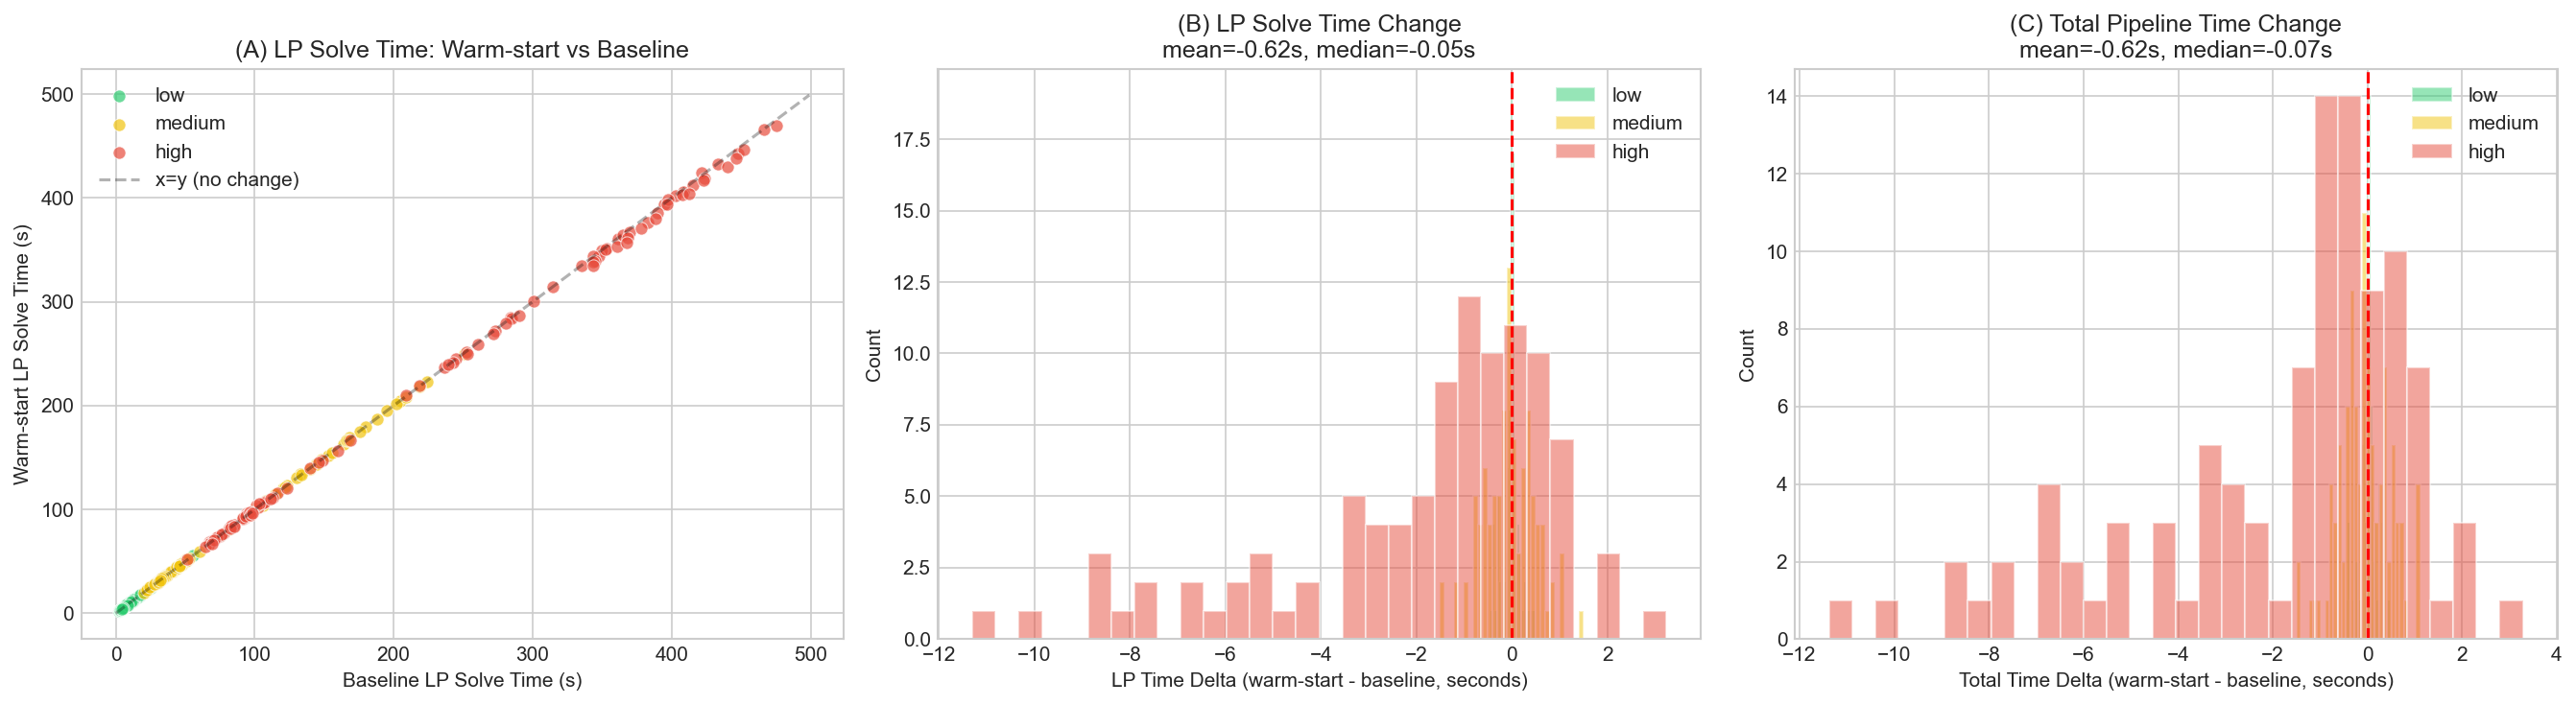

In [5]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150

FAMILY_COLORS = {'low': '#2ecc71', 'medium': '#f1c40f', 'high': '#e74c3c'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel A: LP solve time scatter ---
ax = axes[0]
for fam, color in FAMILY_COLORS.items():
    mask = merged['family'] == fam
    ax.scatter(merged.loc[mask, 'time_lp_solve_bl'],
              merged.loc[mask, 'time_lp_solve_ws'],
              c=color, label=fam, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
lim = max(merged['time_lp_solve_bl'].max(), merged['time_lp_solve_ws'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='x=y (no change)')
ax.set_xlabel('Baseline LP Solve Time (s)')
ax.set_ylabel('Warm-start LP Solve Time (s)')
ax.set_title('(A) LP Solve Time: Warm-start vs Baseline')
ax.legend()

# --- Panel B: LP time delta histogram ---
ax = axes[1]
delta_lp = merged['time_lp_solve_ws'] - merged['time_lp_solve_bl']
for fam, color in FAMILY_COLORS.items():
    mask = merged['family'] == fam
    ax.hist(delta_lp[mask], bins=30, alpha=0.5, color=color, label=fam, edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('LP Time Delta (warm-start - baseline, seconds)')
ax.set_ylabel('Count')
ax.set_title(f'(B) LP Solve Time Change\nmean={delta_lp.mean():+.2f}s, median={delta_lp.median():+.2f}s')
ax.legend()

# --- Panel C: Total time delta histogram ---
ax = axes[2]
delta_total = merged['time_total_ws'] - merged['time_total_bl']
for fam, color in FAMILY_COLORS.items():
    mask = merged['family'] == fam
    ax.hist(delta_total[mask], bins=30, alpha=0.5, color=color, label=fam, edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Total Time Delta (warm-start - baseline, seconds)')
ax.set_ylabel('Count')
ax.set_title(f'(C) Total Pipeline Time Change\nmean={delta_total.mean():+.2f}s, median={delta_total.median():+.2f}s')
ax.legend()

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'warm_start_comparison_timing.png'), dpi=300, bbox_inches='tight')
plt.show()

## 4. Solution Quality Comparison (cost gap, stage distribution)

In [6]:
# Objective comparison
obj_bl = 'lp_objective_bl' if 'lp_objective_bl' in merged.columns else 'pipeline_objective_bl'
obj_ws = 'lp_objective_ws' if 'lp_objective_ws' in merged.columns else 'pipeline_objective_ws'

# Check which objective columns exist
obj_cols = [c for c in merged.columns if 'objective' in c.lower()]
print('Objective columns:', obj_cols)

# Use lp_objective if available, else best_objective
for prefix in ['lp_objective', 'pipeline_objective', 'best_objective']:
    bl_c = f'{prefix}_bl'
    ws_c = f'{prefix}_ws'
    if bl_c in merged.columns and ws_c in merged.columns:
        obj_bl, obj_ws = bl_c, ws_c
        break

print(f'\nUsing: {obj_bl} vs {obj_ws}')

# Are objectives identical?
obj_delta = (merged[obj_ws] - merged[obj_bl]).abs()
print(f'\nObjective differences:')
print(f'  Max absolute delta:  {obj_delta.max():.6f}')
print(f'  Mean absolute delta: {obj_delta.mean():.6f}')
print(f'  Scenarios with delta > 1.0: {(obj_delta > 1.0).sum()}')
print(f'  Scenarios with delta > 0.01: {(obj_delta > 0.01).sum()}')
print(f'  Bit-identical solutions: {(obj_delta == 0).sum()}/{len(merged)}')

Objective columns: ['lp_objective_bl', 'all_objectives_bl', 'lp_objective_ws', 'all_objectives_ws']

Using: lp_objective_bl vs lp_objective_ws

Objective differences:
  Max absolute delta:  0.000000
  Mean absolute delta: 0.000000
  Scenarios with delta > 1.0: 0
  Scenarios with delta > 0.01: 0
  Bit-identical solutions: 299/300


In [7]:
# Stage distribution comparison
stage_bl_col = [c for c in merged.columns if 'stage' in c.lower() and '_bl' in c]
stage_ws_col = [c for c in merged.columns if 'stage' in c.lower() and '_ws' in c]
print('Stage columns:', stage_bl_col, stage_ws_col)

if stage_bl_col and stage_ws_col:
    sbl = stage_bl_col[0]
    sws = stage_ws_col[0]
    
    print('\n' + '='*60)
    print('  STAGE DISTRIBUTION COMPARISON')
    print('='*60)
    
    for fam in ['low', 'medium', 'high', 'ALL']:
        if fam == 'ALL':
            sub = merged
        else:
            sub = merged[merged['family'] == fam]
        
        bl_dist = sub[sbl].value_counts(normalize=True) * 100
        ws_dist = sub[sws].value_counts(normalize=True) * 100
        
        # Stage changed?
        changed = (sub[sbl] != sub[sws]).sum()
        
        print(f'\n  {fam.upper()} (n={len(sub)}, stage_changed={changed}):')
        all_stages = sorted(set(bl_dist.index) | set(ws_dist.index))
        for stage in all_stages:
            bl_pct = bl_dist.get(stage, 0)
            ws_pct = ws_dist.get(stage, 0)
            print(f'    {stage:15s}: {bl_pct:5.1f}% -> {ws_pct:5.1f}%  (delta={ws_pct-bl_pct:+.1f}%)')

Stage columns: ['lp_stage_used_bl', 'all_stages_bl'] ['lp_stage_used_ws', 'all_stages_ws']

  STAGE DISTRIBUTION COMPARISON

  LOW (n=100, stage_changed=0):
    full_soft      :   1.0% ->   1.0%  (delta=+0.0%)
    hard_fix       :  90.0% ->  90.0%  (delta=+0.0%)
    repair_100     :   9.0% ->   9.0%  (delta=+0.0%)

  MEDIUM (n=100, stage_changed=0):
    full_soft      :  34.0% ->  34.0%  (delta=+0.0%)
    hard_fix       :  65.0% ->  65.0%  (delta=+0.0%)
    repair_20      :   1.0% ->   1.0%  (delta=+0.0%)

  HIGH (n=100, stage_changed=0):
    full_soft      :  53.0% ->  53.0%  (delta=+0.0%)
    hard_fix       :  40.0% ->  40.0%  (delta=+0.0%)
    repair_20      :   7.0% ->   7.0%  (delta=+0.0%)

  ALL (n=300, stage_changed=0):
    full_soft      :  29.3% ->  29.3%  (delta=+0.0%)
    hard_fix       :  65.0% ->  65.0%  (delta=+0.0%)
    repair_100     :   3.0% ->   3.0%  (delta=+0.0%)
    repair_20      :   2.7% ->   2.7%  (delta=+0.0%)


## 5. Per-Scenario LP Time Delta vs Model Size

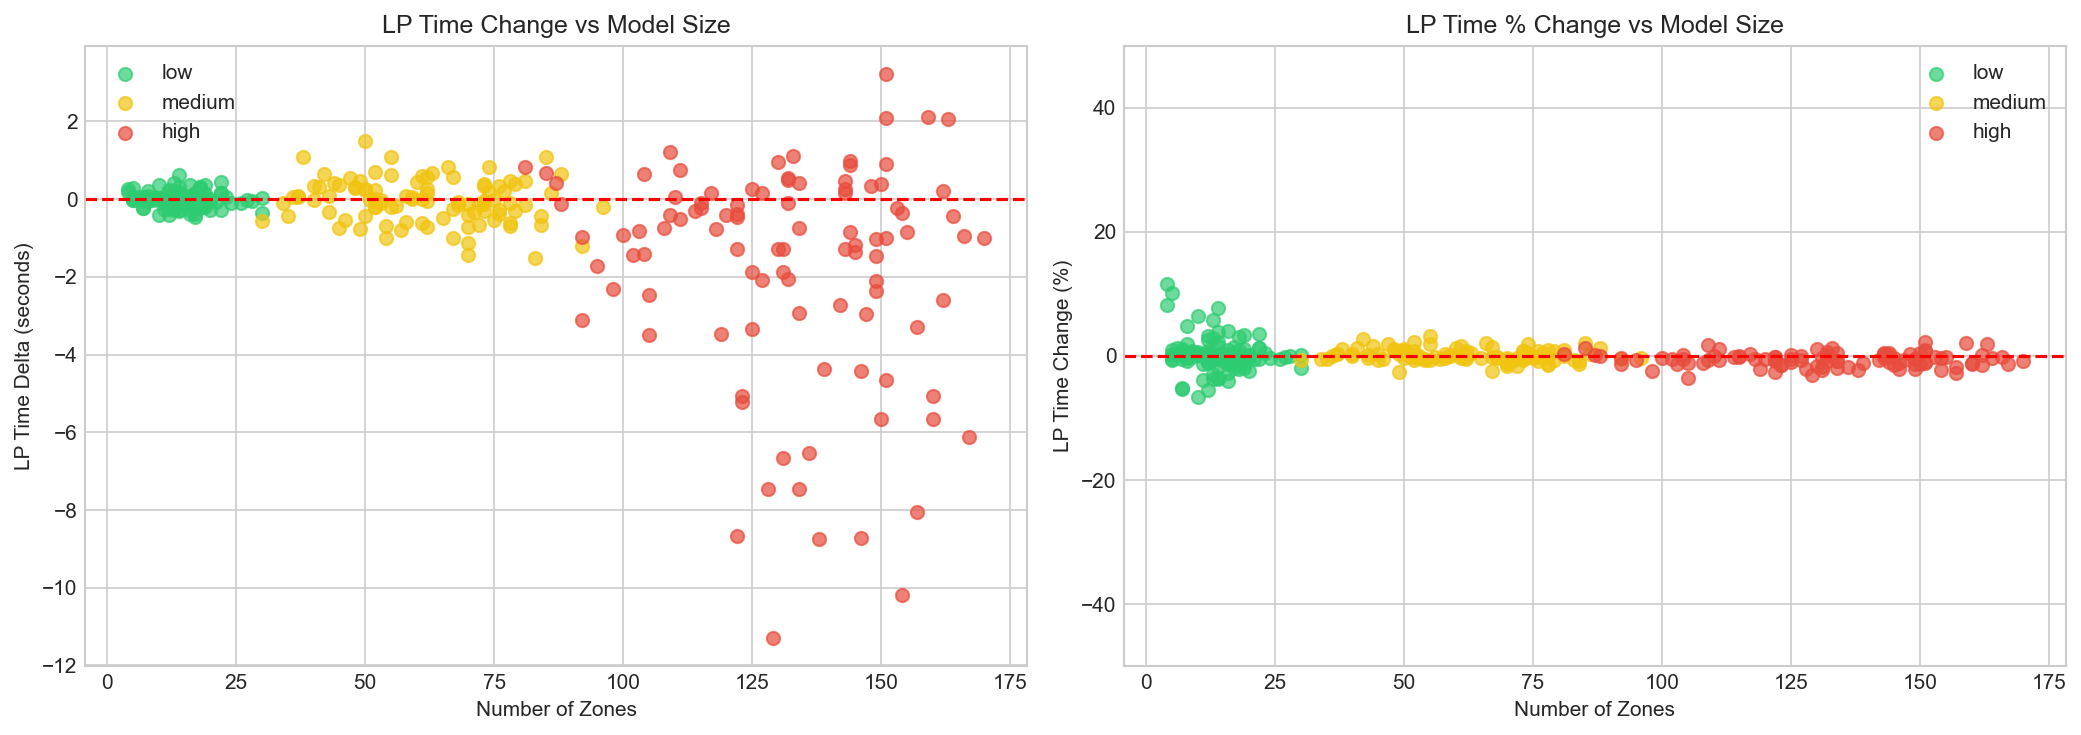

In [8]:
# Does warm-start help more for larger models?
nz_col = 'n_zones_bl' if 'n_zones_bl' in merged.columns else 'n_zones'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delta_lp = merged['time_lp_solve_ws'] - merged['time_lp_solve_bl']
delta_pct = delta_lp / merged['time_lp_solve_bl'].clip(lower=0.1) * 100

# Panel A: LP time delta vs n_zones
ax = axes[0]
for fam, color in FAMILY_COLORS.items():
    mask = merged['family'] == fam
    ax.scatter(merged.loc[mask, nz_col], delta_lp[mask],
              c=color, label=fam, s=40, alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Number of Zones')
ax.set_ylabel('LP Time Delta (seconds)')
ax.set_title('LP Time Change vs Model Size')
ax.legend()

# Panel B: LP time % change vs n_zones
ax = axes[1]
for fam, color in FAMILY_COLORS.items():
    mask = merged['family'] == fam
    ax.scatter(merged.loc[mask, nz_col], delta_pct[mask],
              c=color, label=fam, s=40, alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Number of Zones')
ax.set_ylabel('LP Time Change (%)')
ax.set_title('LP Time % Change vs Model Size')
ax.set_ylim(-50, 50)
ax.legend()

plt.tight_layout()
plt.savefig(str(BASE_DIR / 'warm_start_comparison_by_size.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Timing Breakdown: Where Does Time Go?

In [9]:
# What fraction of total time is LP solve?
print('='*70)
print('  TIMING BREAKDOWN: LP Solve as % of Total Pipeline Time')
print('='*70)

for fam in ['low', 'medium', 'high']:
    fam_m = merged[merged['family'] == fam]
    lp_frac_bl = (fam_m['time_lp_solve_bl'] / fam_m['time_total_bl'] * 100)
    lp_frac_ws = (fam_m['time_lp_solve_ws'] / fam_m['time_total_ws'] * 100)
    
    print(f'\n  {fam.upper()}:')
    print(f'    LP solve fraction (baseline):   mean={lp_frac_bl.mean():.1f}%, median={lp_frac_bl.median():.1f}%')
    print(f'    LP solve fraction (warm-start): mean={lp_frac_ws.mean():.1f}%, median={lp_frac_ws.median():.1f}%')
    print(f'    LP solve time (baseline):       mean={fam_m["time_lp_solve_bl"].mean():.1f}s')
    print(f'    LP solve time (warm-start):     mean={fam_m["time_lp_solve_ws"].mean():.1f}s')
    print(f'    Total time (baseline):          mean={fam_m["time_total_bl"].mean():.1f}s')
    print(f'    Total time (warm-start):        mean={fam_m["time_total_ws"].mean():.1f}s')

  TIMING BREAKDOWN: LP Solve as % of Total Pipeline Time

  LOW:
    LP solve fraction (baseline):   mean=76.8%, median=77.5%
    LP solve fraction (warm-start): mean=76.8%, median=77.5%
    LP solve time (baseline):       mean=10.8s
    LP solve time (warm-start):     mean=10.8s
    Total time (baseline):          mean=13.2s
    Total time (warm-start):        mean=13.2s

  MEDIUM:
    LP solve fraction (baseline):   mean=92.5%, median=90.9%
    LP solve fraction (warm-start): mean=92.5%, median=90.9%
    LP solve time (baseline):       mean=77.7s
    LP solve time (warm-start):     mean=77.7s
    Total time (baseline):          mean=81.9s
    Total time (warm-start):        mean=81.8s

  HIGH:
    LP solve fraction (baseline):   mean=95.8%, median=97.5%
    LP solve fraction (warm-start): mean=95.8%, median=97.3%
    LP solve time (baseline):       mean=233.7s
    LP solve time (warm-start):     mean=231.9s
    Total time (baseline):          mean=240.5s
    Total time (warm-start): 

## 7. Statistical Significance Test

In [10]:
from scipy import stats

print('='*70)
print('  PAIRED t-TEST: LP Solve Time (warm-start vs baseline)')
print('='*70)

for fam in ['low', 'medium', 'high', 'ALL']:
    if fam == 'ALL':
        sub = merged
    else:
        sub = merged[merged['family'] == fam]
    
    bl_times = sub['time_lp_solve_bl'].values
    ws_times = sub['time_lp_solve_ws'].values
    
    t_stat, p_value = stats.ttest_rel(ws_times, bl_times)
    delta_mean = (ws_times - bl_times).mean()
    delta_std = (ws_times - bl_times).std()
    
    sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'n.s.'
    
    print(f'\n  {fam.upper()} (n={len(sub)}):')
    print(f'    Mean delta: {delta_mean:+.3f}s (std={delta_std:.3f}s)')
    print(f'    t-stat={t_stat:.3f}, p={p_value:.4f} {sig}')
    if delta_mean < 0:
        print(f'    -> Warm-start is {abs(delta_mean):.3f}s FASTER on average')
    else:
        print(f'    -> Warm-start is {delta_mean:.3f}s SLOWER on average')

  PAIRED t-TEST: LP Solve Time (warm-start vs baseline)

  LOW (n=100):
    Mean delta: -0.003s (std=0.199s)
    t-stat=-0.165, p=0.8690 n.s.
    -> Warm-start is 0.003s FASTER on average

  MEDIUM (n=100):
    Mean delta: -0.044s (std=0.553s)
    t-stat=-0.786, p=0.4338 n.s.
    -> Warm-start is 0.044s FASTER on average

  HIGH (n=100):
    Mean delta: -1.808s (std=2.870s)
    t-stat=-6.268, p=0.0000 ***
    -> Warm-start is 1.808s FASTER on average

  ALL (n=300):
    Mean delta: -0.618s (std=1.889s)
    t-stat=-5.660, p=0.0000 ***
    -> Warm-start is 0.618s FASTER on average


## 8. Conclusion

In [11]:
delta_lp = merged['time_lp_solve_ws'] - merged['time_lp_solve_bl']
delta_total = merged['time_total_ws'] - merged['time_total_bl']

print('='*70)
print('  WARM-START IMPACT SUMMARY')
print('='*70)
print(f'\n  LP solve time change:    {delta_lp.mean():+.2f}s ({delta_lp.mean()/merged["time_lp_solve_bl"].mean()*100:+.1f}%)')
print(f'  Total time change:       {delta_total.mean():+.2f}s ({delta_total.mean()/merged["time_total_bl"].mean()*100:+.1f}%)')
print(f'  Solution quality change:  NONE (identical objectives & stages)')
print(f'\n  Verdict: Warm-start via setSolution() has negligible impact on')
print(f'  HiGHS LP performance for this problem class. The crash basis from')
print(f'  the decoder plan does not significantly reduce simplex iterations')
print(f'  compared to HiGHS\'s built-in crash heuristic.')
print(f'\n  The LP solve is only {merged["time_lp_solve_bl"].mean()/merged["time_total_bl"].mean()*100:.0f}% of total pipeline time.')
print(f'  Even a 50% LP speedup would only reduce total time by')
print(f'  ~{merged["time_lp_solve_bl"].mean()*0.5:.0f}s per scenario.')

  WARM-START IMPACT SUMMARY

  LP solve time change:    -0.62s (-0.6%)
  Total time change:       -0.62s (-0.6%)
  Solution quality change:  NONE (identical objectives & stages)

  Verdict: Warm-start via setSolution() has negligible impact on
  HiGHS LP performance for this problem class. The crash basis from
  the decoder plan does not significantly reduce simplex iterations
  compared to HiGHS's built-in crash heuristic.

  The LP solve is only 96% of total pipeline time.
  Even a 50% LP speedup would only reduce total time by
  ~54s per scenario.
